In [1]:
### import IPython.display as ipyd
from pyspark.sql.functions import col, regexp_replace, monotonically_increasing_id
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, monotonically_increasing_id, regexp_replace

In [2]:
spark = SparkSession.builder.getOrCreate()

df = spark.read.parquet("/home/iceberg/data/licitacoes")

df = df.withColumn("id", monotonically_increasing_id())
ids_to_remove = [146031822003, 231928237654, 206158470397, 188979183588]
df = df.filter(~col("id").isin(ids_to_remove))
df_typecasted = df.withColumn("ano", col("ano").cast("int")) \
                  .withColumn("mes", col("mes").cast("int")) \
                  .withColumn("Valor Licitação", regexp_replace(col("Valor Licitação"), ",", ".").cast("float"))
cardinality = sorted([
    (column, df_typecasted.select(F.approx_count_distinct(column)).collect()[0][0])
    for column in df_typecasted.columns if column != "id"
], key=lambda x: x[1])
ordered_cols = [c for c, _ in cardinality]

df_final = df_typecasted.select(ordered_cols) \
                        .orderBy(*[c for c, _ in cardinality])

26/04/15 23:30:48 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

In [ ]:
spark.sql("CREATE NAMESPACE IF NOT EXISTS demo.licitacoes")

df_final.writeTo("demo.licitacoes.licitacoes") \
        .tableProperty("format-version", "2") \
        .partitionedBy("ano", "mes") \
        .createOrReplace()

[Stage 59:======================================================> (27 + 1) / 28]

---

In [4]:
df.printSchema()

root
 |-- Número Licitação: string (nullable = true)
 |-- Código UG: string (nullable = true)
 |-- Nome UG: string (nullable = true)
 |-- Código Modalidade Compra: string (nullable = true)
 |-- Modalidade Compra: string (nullable = true)
 |-- Número Processo: string (nullable = true)
 |-- Objeto: string (nullable = true)
 |-- Situação Licitação: string (nullable = true)
 |-- Código Órgão Superior: string (nullable = true)
 |-- Nome Órgão Superior: string (nullable = true)
 |-- Código Órgão: string (nullable = true)
 |-- Nome Órgão: string (nullable = true)
 |-- UF: string (nullable = true)
 |-- Município: string (nullable = true)
 |-- Data Resultado Compra: string (nullable = true)
 |-- Data Abertura: string (nullable = true)
 |-- Valor Licitação: string (nullable = true)
 |-- ano: integer (nullable = true)
 |-- mes: integer (nullable = true)
 |-- id: long (nullable = false)



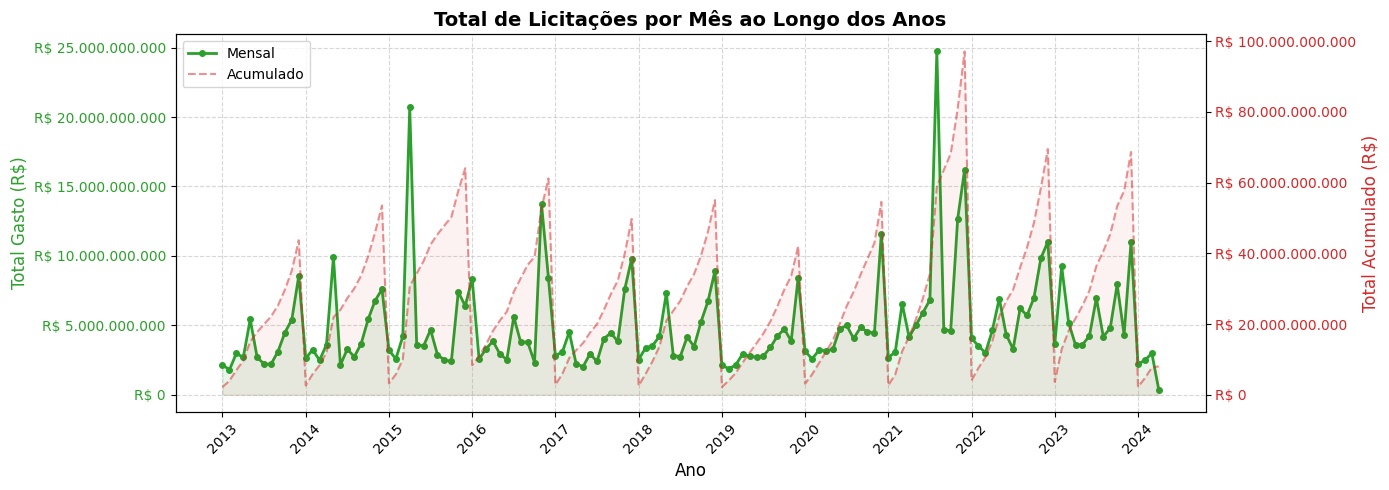

In [7]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum as spark_sum, col

pdf = (
    df_typecasted
      .filter(col("Valor Licitação") > 0)
      .groupBy("ano", "mes")
      .agg(spark_sum("Valor Licitação").alias("total_valor"))
      .orderBy("ano", "mes")
      .toPandas()
)

# Continuous month index
pdf["month_index"] = (pdf["ano"] - pdf["ano"].min()) * 12 + (pdf["mes"] - 1)

# Cumulative sum per year
pdf["cumsum_valor"] = pdf.groupby("ano")["total_valor"].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))

# ── Backdrop: cumsum ──────────────────────────────────────────────────────────
ax2 = ax.twinx()
ax2.fill_between(pdf["month_index"], pdf["cumsum_valor"], alpha=0.06, color="#d62728")
ax2.plot(pdf["month_index"], pdf["cumsum_valor"], linewidth=1.5, color="#d62728", linestyle="--", alpha=0.5, label="Acumulado")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}".replace(",", ".")))
ax2.set_ylabel("Total Acumulado (R$)", fontsize=12, color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

# ── Main: monthly total ───────────────────────────────────────────────────────
ax.plot(pdf["month_index"], pdf["total_valor"], marker="o", linewidth=2, color="#2ca02c", markersize=4, label="Mensal", zorder=3)
ax.fill_between(pdf["month_index"], pdf["total_valor"], alpha=0.1, color="#2ca02c")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}".replace(",", ".")))
ax.set_ylabel("Total Gasto (R$)", fontsize=12, color="#2ca02c")
ax.tick_params(axis="y", labelcolor="#2ca02c")

# ── Year ticks ────────────────────────────────────────────────────────────────
years = pdf.drop_duplicates("ano").sort_values("ano")
tick_positions = ((years["ano"] - pdf["ano"].min()) * 12).tolist()
tick_labels = years["ano"].astype(str).tolist()
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45)

# ── Labels & legend ───────────────────────────────────────────────────────────
ax.set_title("Total de Licitações por Mês ao Longo dos Anos", fontsize=14, fontweight="bold")
ax.set_xlabel("Ano", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

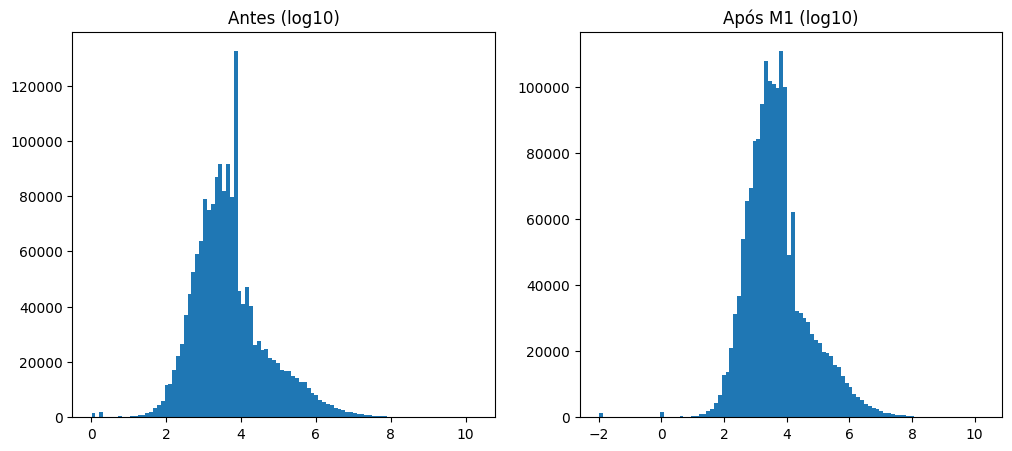

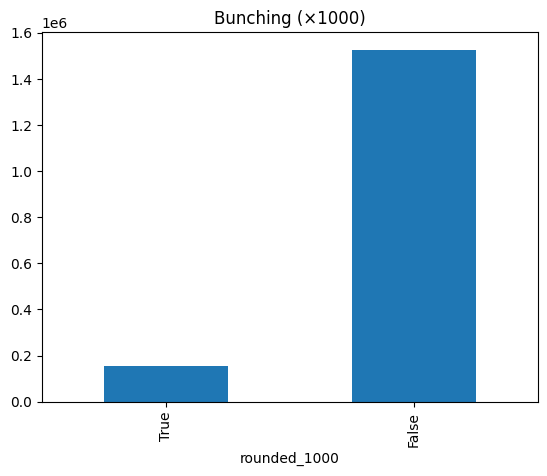

In [7]:
# =========================================
# M1 — ELIGIBILITY FILTER
# =========================================
df_model = (
    df_typecasted
    .withColumn("value", col("Valor Licitação").cast("double"))
    .filter(col("value") > 0)
)

df_model = df_model.withColumn("log_value", F.log10(col("value")))

# -------- VISUALIZAÇÃO M1 --------
pdf_raw   = df_typecasted.select("Valor Licitação").dropna().toPandas()
pdf_model = df_model.select("value", "log_value").dropna().toPandas()

pdf_raw["valor_num"] = pd.to_numeric(pdf_raw["Valor Licitação"], errors="coerce")
pdf_raw = pdf_raw[pdf_raw["valor_num"] > 0].dropna()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(np.log10(pdf_raw["valor_num"] + 1), bins=100)
plt.title("Antes (log10)")
plt.subplot(1, 2, 2)
plt.hist(pdf_model["log_value"], bins=100)
plt.title("Após M1 (log10)")
plt.show()

# BUNCHING — valores redondos (múltiplos de 1000 são mais comuns em licitações)
df_model.withColumn("rounded_1000", col("value") % 1000 == 0) \
    .groupBy("rounded_1000") \
    .count() \
    .toPandas() \
    .set_index("rounded_1000") \
    .plot(kind="bar", legend=False)
plt.title("Bunching (×1000)")
plt.show()

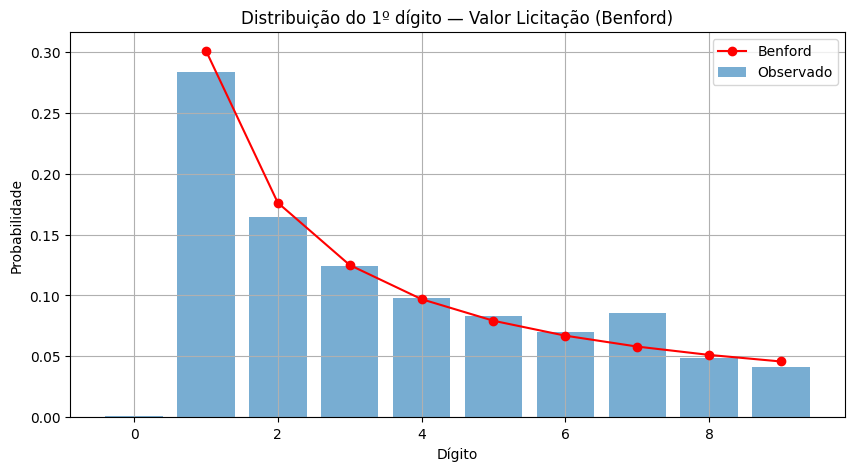

In [8]:
# =========================================
# HELPERS
# =========================================
def first_digit():
    return F.substring(F.regexp_replace(col("value").cast("string"), "[^0-9]", ""), 1, 1).cast("int")

def first_two_digits():
    return F.substring(F.regexp_replace(col("value").cast("string"), "[^0-9]", ""), 1, 2).cast("int")

def last_digit():
    return (col("value") % 10).cast("int")

# =========================================
# FEATURE ENGINEERING
# =========================================
df_feat = df_model \
    .withColumn("d1", first_digit()) \
    .withColumn("d2", first_two_digits()) \
    .withColumn("ld", last_digit())

# -------- Benford 1º dígito --------
df1  = df_feat.withColumn("digit", first_digit())
obs  = df1.groupBy("digit").count().orderBy("digit").toPandas()
obs["p_obs"] = obs["count"] / obs["count"].sum()
exp  = pd.DataFrame({
    "digit": list(range(1, 10)),
    "p_exp": [np.log10(1 + 1/d) for d in range(1, 10)]
})

plt.figure(figsize=(10, 5))
plt.bar(obs["digit"], obs["p_obs"], alpha=0.6, label="Observado")
plt.plot(exp["digit"], exp["p_exp"], color="red", marker="o", label="Benford")
plt.title("Distribuição do 1º dígito — Valor Licitação (Benford)")
plt.xlabel("Dígito")
plt.ylabel("Probabilidade")
plt.legend()
plt.grid()
plt.show()

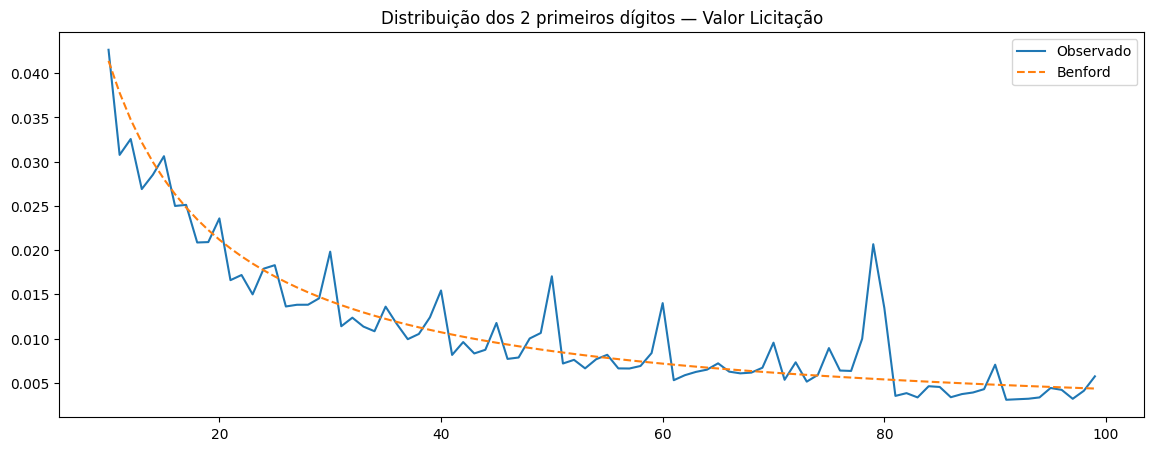

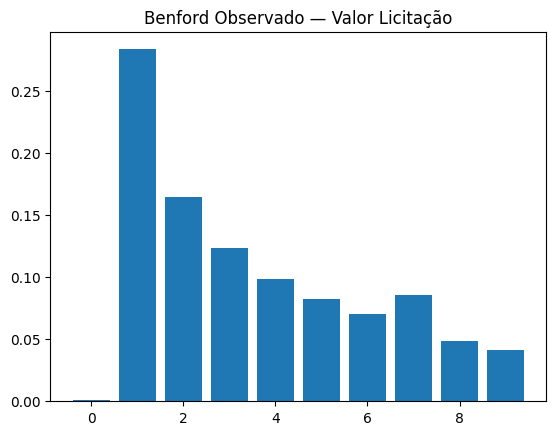

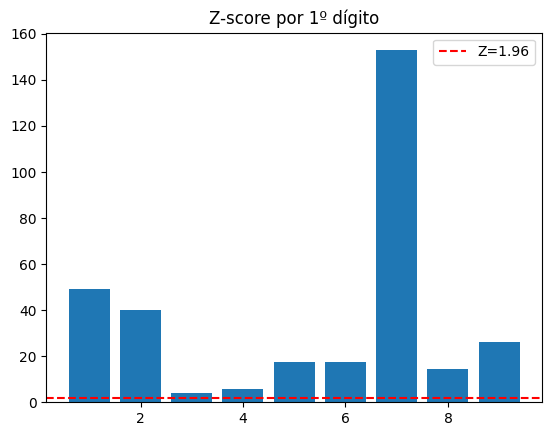

In [9]:
# -------- Benford 2 primeiros dígitos --------
df2   = df_feat.withColumn("digit", first_two_digits()).filter(col("digit").between(10, 99))
obs2  = df2.groupBy("digit").count().orderBy("digit").toPandas()
obs2["p_obs"] = obs2["count"] / obs2["count"].sum()
exp2  = pd.DataFrame({
    "digit": list(range(10, 100)),
    "p_exp": [np.log10(1 + 1/n) for n in range(10, 100)]
})

plt.figure(figsize=(14, 5))
plt.plot(obs2["digit"], obs2["p_obs"], label="Observado")
plt.plot(exp2["digit"], exp2["p_exp"], label="Benford", linestyle="--")
plt.title("Distribuição dos 2 primeiros dígitos — Valor Licitação")
plt.legend()
plt.show()

# =========================================
# M2 — STATISTICAL ENGINE (Z-score Benford)
# =========================================
benford_1d = spark.createDataFrame([
    (d, float(np.log10(1 + 1/d))) for d in range(1, 10)
], ["d1", "p_exp_1d"])

obs_df = df_feat.groupBy("d1").count().withColumnRenamed("count", "O")
N      = obs_df.agg(F.sum("O")).first()[0]
obs_df = obs_df.withColumn("p_obs", col("O") / N)

df_feat = df_feat.join(obs_df.select("d1", "p_obs"), "d1")
df_feat = df_feat.join(benford_1d, "d1")
df_feat = df_feat.withColumn(
    "Z",
    (F.abs(col("p_obs") - col("p_exp_1d")) - (1 / (2 * N))) /
    F.sqrt((col("p_exp_1d") * (1 - col("p_exp_1d"))) / N)
)
df_feat = df_feat.withColumn(
    "ld_score",
    F.when(col("ld") == 0, 1.0).otherwise(0.0)
)

# -------- VISUALIZAÇÃO M2 --------
pdf_obs = obs_df.toPandas()
plt.bar(pdf_obs["d1"], pdf_obs["p_obs"])
plt.title("Benford Observado — Valor Licitação")
plt.show()

pdf_z = df_feat.groupBy("d1").agg(F.avg("Z").alias("Z")).toPandas()
plt.bar(pdf_z["d1"], pdf_z["Z"])
plt.axhline(1.96, color="red", linestyle="--", label="Z=1.96")
plt.title("Z-score por 1º dígito")
plt.legend()
plt.show()

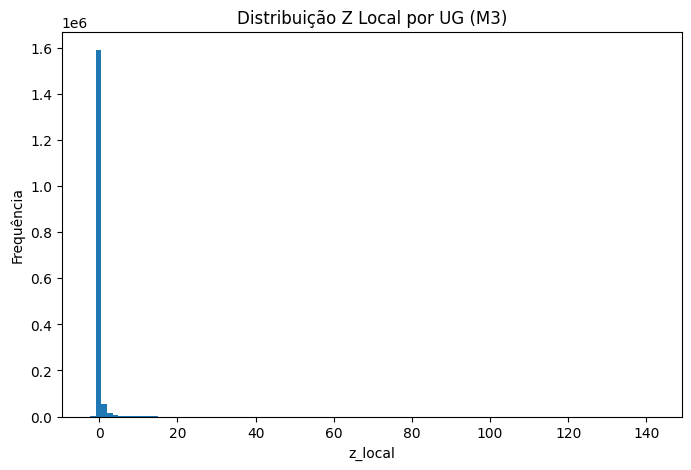

In [10]:
# =========================================
# M3 — MICRO (por Unidade Gestora)
# =========================================
# Agrupa por UG em vez de contrato (não existe contrato neste schema)
w_local = Window.partitionBy("Código UG")

df_feat = df_feat.withColumn("mean_local", F.avg("value").over(w_local))
df_feat = df_feat.withColumn("std_local",  F.stddev("value").over(w_local))
df_feat = df_feat.withColumn(
    "z_local",
    F.when(col("std_local") > 0,
           (col("value") - col("mean_local")) / col("std_local")
    ).otherwise(0)
)

pdf_micro = df_feat.select("z_local").dropna().toPandas()
plt.figure(figsize=(8, 5))
plt.hist(pdf_micro["z_local"], bins=100)
plt.title("Distribuição Z Local por UG (M3)")
plt.xlabel("z_local")
plt.ylabel("Frequência")
plt.show()

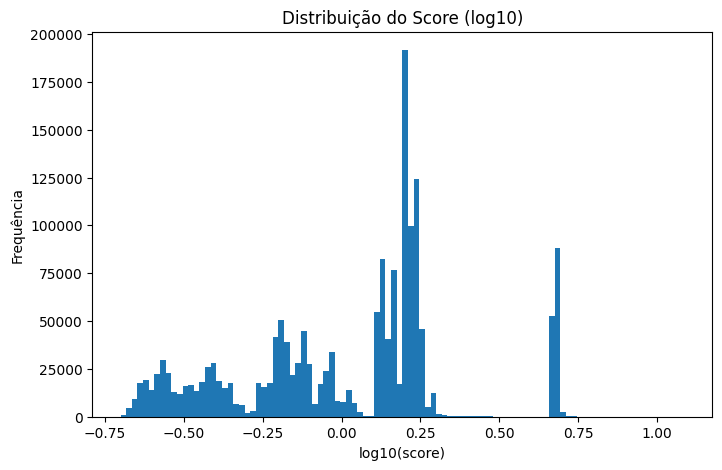

In [11]:
# =========================================
# M4 — SCORE COMPOSTO
# =========================================
if "freq_value" in df_feat.columns:
    df_feat = df_feat.drop("freq_value")

# distância de arredondamento (base 1000, comum em licitações)
df_feat = df_feat.withColumn(
    "round_dist",
    F.abs(col("value") - (F.round(col("value") / 1000) * 1000)) / 1000
)

# frequência do mesmo valor exato
freq_df = df_feat.groupBy("value").count().withColumnRenamed("count", "freq_value")
df_feat  = df_feat.drop("freq_value")
df_feat  = df_feat.join(freq_df, "value")

max_freq = df_feat.agg(F.max("freq_value")).collect()[0][0]

df_feat = df_feat.withColumn("Z_norm",      F.abs(col("Z")) / 10)
df_feat = df_feat.withColumn("z_local_norm", F.abs(col("z_local")) / 3)
df_feat = df_feat.withColumn("freq_norm",   col("freq_value") / F.lit(max_freq))
df_feat = df_feat.withColumn("round_norm",  1 - col("round_dist"))
df_feat = df_feat.withColumn("ld_norm",     col("ld_score"))
df_feat = df_feat.fillna(0)

df_feat = df_feat.withColumn(
    "score",
    0.30 * col("Z_norm") +
    0.25 * col("z_local_norm") +
    0.20 * col("freq_norm") +
    0.15 * col("round_norm") +
    0.10 * col("ld_norm")
)

# -------- VISUALIZAÇÃO M4 --------
pdf_score = df_feat.select("score").dropna().toPandas()
pdf_score = pdf_score[np.isfinite(pdf_score["score"]) & (pdf_score["score"] > 0)]
plt.figure(figsize=(8, 5))
plt.hist(np.log10(pdf_score["score"] + 1e-6), bins=100)
plt.title("Distribuição do Score (log10)")
plt.xlabel("log10(score)")
plt.ylabel("Frequência")
plt.show()


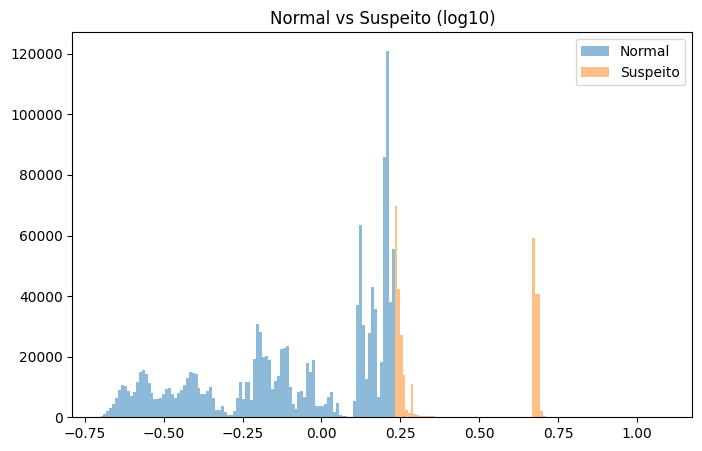

In [12]:
# =========================================
# DETECÇÃO FINAL
# =========================================
threshold = df_feat.select("score").sample(0.2).approxQuantile("score", [0.85], 0.05)[0]

df_result = df_feat.withColumn(
    "suspeito",
    col("score") > threshold
)

# -------- VISUALIZAÇÃO FINAL --------
pdf_final = df_result.select("score", "suspeito").toPandas()
plt.figure(figsize=(8, 5))
plt.hist(np.log10(pdf_final[pdf_final["suspeito"] == False]["score"] + 1e-6), bins=100, alpha=0.5, label="Normal")
plt.hist(np.log10(pdf_final[pdf_final["suspeito"] == True ]["score"] + 1e-6), bins=100, alpha=0.5, label="Suspeito")
plt.title("Normal vs Suspeito (log10)")
plt.legend()
plt.show()


In [13]:
# =========================================
# OUTPUT FINAL
# =========================================
df_result.filter(col("suspeito")) \
    .orderBy(F.desc("score")) \
    .select(
        "Número Licitação",
        "Nome UG",
        "Modalidade Compra",
        "UF",
        "Município",
        "Objeto",
        "value",
        "score"
    ) \
    .show(20, False)

df_result.groupBy("suspeito").agg(
    F.count("*").alias("qtd"),
    F.avg("value").alias("valor_medio"),
    F.avg("score").alias("score_medio")
).show()

+----------------+---------------------------------------------+----------------------------+---+---------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------+------------------+
|Número Licitação|Nome UG                                      |Modalidade Compra           |UF |Município      |Objeto                                                                                                                                                                                                                                                     

[Stage 366:======>          (3 + 5) / 8][Stage 371:>                (0 + 3) / 3]

+--------+-------+------------------+------------------+
|suspeito|    qtd|       valor_medio|       score_medio|
+--------+-------+------------------+------------------+
|    true| 318244| 983067.6123743467| 3.142769541435234|
|   false|1359778|260507.99877410292|0.9673692873471141|
+--------+-------+------------------+------------------+

